In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
import anisotropy
import seaborn
from common import normalize

In [2]:
def generate_true(*, total_intensity, size):
    ani = pywt.data.demo_signal("blocks", size)
    ani = 0.1 + 0.8 * normalize(ani)
    images = anisotropy.intensity_from_anisotropy(ani, total_intensity)
    return images

## Figure

In [3]:
rng = np.random.default_rng(42)

size = 2**8
sigma = 3
N0 = 50

total_intensity = rng.uniform(
    N0,
    N0 * np.repeat([1, 2, 5, 10], size//4)[:, None],
    size=(size, size),
)
images_truth = generate_true(
    total_intensity=total_intensity,
    size=size,
)
images = np.random.default_rng(42).poisson(images_truth)
images = {
    "true": images_truth,
    "measured": images,
    "independent": anisotropy.independent_binlets(images, sigma=sigma),
    "binlets\nanisotropy": anisotropy.joint_binlets(images, sigma=sigma),
}

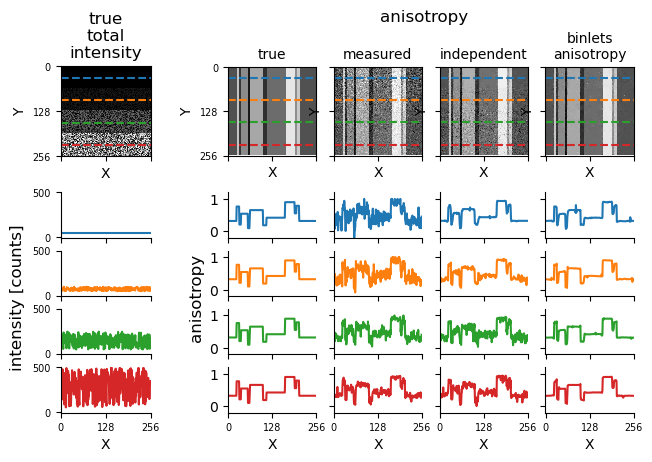

In [4]:
def plot_line(ax_line, ax_image, image, line, color):
    ax_line.plot(image[line], color=color)
    ax_image.axhline(line, color=color, linestyle="--")


def plot_image(ax, image, **kwargs):
    ax.imshow(
        image,
        interpolation="none",
        cmap="gray",
        rasterized=True,
        **kwargs,
    )


def plot_row(axes, image, lines, **kwargs):
    ax_image, *ax_lines = axes

    plot_image(ax_image, image, **kwargs)
    for ax, (i, line) in zip(ax_lines, enumerate(lines)):
        plot_line(
            ax_line=ax,
            ax_image=ax_image,
            image=image,
            line=line,
            color=f"C{i}",
        )


lines, step = np.linspace(0, size, 4, endpoint=False, retstep=True)
lines += step / 2
lines = lines.astype(int)

fig = plt.figure()
figs = fig.subfigures(1, 2, width_ratios=[1, 4.5])

axes = figs[0].subplots(
    5,
    1,
    sharex=True,
    height_ratios=[3, 1, 1, 1, 1],
)
axes[0].set(title="true\ntotal\nintensity")
plot_row(axes, total_intensity, lines)

for ax in axes[1:]:
    ax.set(ylim=(-5, 500))

figs[1].suptitle("anisotropy", y=0.95)
axes = figs[1].subplots(
    5,
    4,
    sharex=True,
    sharey="row",
    height_ratios=[3, 1, 1, 1, 1],
)

for ax, (label, image) in zip(axes.T, images.items()):
    ax[0].set_title(label, fontsize="medium")
    plot_row(
        ax,
        anisotropy.anisotropy(image),
        vmin=0,
        vmax=1,
        # anisotropy.anisotropy(image) - anisotropy.anisotropy(images["Ground Truth"]), vmin=-.1, vmax=.1, cmap="seismic",
        lines=lines,
    )

    for ax in ax[1:]:
        ax.set(ylim=(-0.2, 1.2))

for ax in figs[0].axes[1:]:
    seaborn.despine(ax=ax)

for ax in figs[1].axes[4:]:
    seaborn.despine(ax=ax)

for ax in (figs[0].axes[0], *figs[1].axes[:4]):
    ax.set(
        xticks=(0, 128, 256),
        yticks=(0, 128, 256),
        ylabel="Y",
        xlabel="X",
    )
for ax in (figs[0].axes[0], figs[1].axes[0]):
    ax.set_yticklabels((0, 128, 256), fontsize="x-small")
for ax in (figs[0].axes[-1], *figs[1].axes[-4:]):
    ax.set(xlabel="X")
    ax.set_xticklabels((0, 128, 256), fontsize="x-small")
for ax in figs[0].axes[1:]:
    ax.set_yticks((0, 500), (0, 500), fontsize="x-small")

y = 0.35
figs[0].supylabel("intensity [counts]", y=y, x=-0.31)
figs[1].supylabel("anisotropy", y=y, x=0.05)

path = "../article/figures/5_anisotropy_2D"
fig.savefig(path + ".png", bbox_inches="tight")
fig.savefig(path + ".pdf", bbox_inches="tight")